In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

In [41]:
file_2023 = "DATA TABLE-2023- SALE 50.xlsx"
file_2024 = "DATA TABLE-2024- SALE  51.xlsx"
file_2025 = "DATA TABLE-2025- SALE  46- up to November.xlsx"

df_2023 = pd.read_excel(file_2023, sheet_name="DATA")
df_2024 = pd.read_excel(file_2024, sheet_name="DATA")
df_2025 = pd.read_excel(file_2025, sheet_name="DATA")

df_all = pd.concat([df_2023, df_2024, df_2025], ignore_index=True)
print("df_all:", df_all.shape)

df_all: (1503888, 33)


In [42]:
df_2023.head()

,YEAR,MONTH,BROKER,LOT NO,SALE NO,INV NO,MF,REF,MARK,SALE TYPE,...,BUYER CODE,BUYER NAME,CHEST,CATEGORY,MF/BF,MFREF,FACTORY,ELE1,ELE2,GROUP
0,2023,JAN,AS,1,1,414,MFH,344,GALEWELA SUPER,PUBLIC AUCTION,...,J2,A.F. JONES (EXPORTS) CE,20.0,EX-ESTATE,MF,MF0344,MATALE WEST,Medium,WM,0
1,2023,JAN,AS,2,1,415,MFH,344,GALEWELA SUPER,PUBLIC AUCTION,...,J2,A.F. JONES (EXPORTS) CE,20.0,EX-ESTATE,MF,MF0344,MATALE WEST,Medium,WM,0
2,2023,JAN,AS,4,1,66,MF,62,KELANEIYA & BRAEMAR,PUBLIC AUCTION,...,S080,SUNSHINE CONSUMER LANKA,10.0,EX-ESTATE,MF,MF0062,KELANEIYA,High,WH,0
3,2023,JAN,AS,5,1,248R,MF,1003,SHANNON,PUBLIC AUCTION,...,D332,DILMA CEYLON TEA CO PLC,10.0,EX-ESTATE,MF,MF1003,SHANNON,High,WH,0
4,2023,JAN,AS,7,1,235R,MF,1003,SHANNON,PUBLIC AUCTION,...,U102,UNI WORLD TEAS (PVT) LT,20.0,EX-ESTATE,MF,MF1003,SHANNON,High,WH,0


In [43]:
df_all.head()

,YEAR,MONTH,BROKER,LOT NO,SALE NO,INV NO,MF,REF,MARK,SALE TYPE,...,ELE1,ELE2,GROUP,PLANTATION,COMB. ELEV.,AGRO,CTC/ORTHODOX,DENSITY,CODE,density2
0,2023,JAN,AS,1,1,414,MFH,344,GALEWELA SUPER,PUBLIC AUCTION,...,Medium,WM,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023,JAN,AS,2,1,415,MFH,344,GALEWELA SUPER,PUBLIC AUCTION,...,Medium,WM,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023,JAN,AS,4,1,66,MF,62,KELANEIYA & BRAEMAR,PUBLIC AUCTION,...,High,WH,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023,JAN,AS,5,1,248R,MF,1003,SHANNON,PUBLIC AUCTION,...,High,WH,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023,JAN,AS,7,1,235R,MF,1003,SHANNON,PUBLIC AUCTION,...,High,WH,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
df_all.columns.tolist()

['YEAR',
 'MONTH',
 'BROKER',
 'LOT NO',
 'SALE NO',
 'INV NO',
 'MF',
 'REF',
 'MARK',
 'SALE TYPE',
 'GRADE',
 'QTY',
 'PRICE',
 'PRO',
 'TYPE',
 'ELE',
 'BUYER CODE',
 'BUYER NAME',
 'CHEST',
 'CATEGORY',
 'MF/BF',
 'MFREF',
 'FACTORY',
 'ELE1',
 'ELE2',
 'GROUP',
 'PLANTATION',
 'COMB. ELEV.',
 'AGRO',
 'CTC/ORTHODOX',
 'DENSITY',
 'CODE',
 'density2']

In [45]:
# 2) Auto-detect columns

In [46]:
def find_col(df, candidates):
    cols_upper = {c.upper(): c for c in df.columns}
    for cand in candidates:
        if cand.upper() in cols_upper:
            return cols_upper[cand.upper()]
    return None

col_year  = find_col(df_all, ["YEAR", "YR"])
col_sale  = find_col(df_all, ["SALE NO", "SALE_NO", "SALENO", "SALE"])
col_grade = find_col(df_all, ["GRADE", "GRD"])
col_price = find_col(df_all, ["PRICE", "AVG_PRICE", "AVG PRICE", "AVERAGE PRICE"])
col_qty   = find_col(df_all, ["QTY", "QUANTITY", "QTY SOLD", "QTY_SOLD"])
col_ele   = find_col(df_all, ["ELE1", "ELEVATION", "ELEV", "ELE"])

print("Detected columns ->",
      "YEAR:", col_year, "| SALE:", col_sale, "| GRADE:", col_grade,
      "| PRICE:", col_price, "| QTY:", col_qty, "| ELE:", col_ele)

missing = [name for name, v in [("YEAR", col_year), ("SALE", col_sale), ("GRADE", col_grade), ("PRICE", col_price), ("ELE", col_ele)] if v is None]
if missing:
    raise ValueError(f"Missing required columns in your file: {missing}. Print df_all.columns and map manually.")

# Standardize names
df = df_all.rename(columns={
    col_year: "YEAR",
    col_sale: "SALE_NO",
    col_grade: "GRADE",
    col_price: "PRICE",
    col_ele: "ELE1",
    **({col_qty: "QTY"} if col_qty is not None else {})
}).copy()


Detected columns -> YEAR: YEAR | SALE: SALE NO | GRADE: GRADE | PRICE: PRICE | QTY: QTY | ELE: ELE1


In [47]:
# 3) Clean + create week_id + elevation/grade

In [48]:
df["YEAR"] = pd.to_numeric(df["YEAR"], errors="coerce")
df["SALE_NO"] = pd.to_numeric(df["SALE_NO"], errors="coerce")
df["PRICE"] = pd.to_numeric(df["PRICE"], errors="coerce")
if "QTY" in df.columns:
    df["QTY"] = pd.to_numeric(df["QTY"], errors="coerce")

df = df.dropna(subset=["YEAR", "SALE_NO", "GRADE", "PRICE", "ELE1"]).copy()

# week_id = YYYYSS (example: 202401)
df["week_id"] = (df["YEAR"].astype(int) * 100) + (df["SALE_NO"].astype(int))

# elevation mapping
df["elevation"] = df["ELE1"].astype(str).str.strip().str.title()
df["elevation"] = df["elevation"].replace({"Medium": "Mid"})  # keep this
df["grade"] = df["GRADE"].astype(str).str.strip().str.upper()


In [49]:
# 4) Filter ONLY high elevation

In [50]:
df_high = df[df["elevation"] == "High"].copy()
print("df_high:", df_high.shape)

df_high: (235107, 36)


In [51]:
# 5) Weekly aggregation (high × Grade × Week)

In [52]:
if "QTY" in df_high.columns:
    tmp = df_high.copy()
    tmp["PQ"] = tmp["PRICE"] * tmp["QTY"]

    weekly_high = tmp.groupby(["week_id","grade"], as_index=False).agg(
        value=("PQ", "sum"),
        qty_sold=("QTY", "sum")
    )
    weekly_high["avg_price"] = weekly_high["value"] / weekly_high["qty_sold"].replace(0, np.nan)
    weekly_high = weekly_high[["week_id","grade","avg_price","qty_sold"]].sort_values(["week_id","grade"])
else:
    weekly_high = (
        df_high.groupby(["week_id","grade"], as_index=False)
        .agg(avg_price=("PRICE","mean"))
        .sort_values(["week_id","grade"])
    )

print("weekly_high:", weekly_high.shape)
weekly_high.head()

weekly_high: (8632, 4)


,week_id,grade,avg_price,qty_sold
0,202301,BM,786.638743,20055.0
1,202301,BOP,1504.226481,103585.0
2,202301,BOP1,1669.095128,4310.0
3,202301,BOP1A,833.439490,9420.0
4,202301,BOPA,1021.536211,13670.0


In [53]:
real_counts_high = (weekly_high.dropna(subset=["avg_price"])
                    .groupby("grade")["week_id"]
                    .nunique()
                    .rename("real_weeks")
                    .reset_index())

print("real_counts_high sample:")
print(real_counts_high.sort_values("real_weeks").head(20))

real_counts_high sample:
          grade  real_weeks
278  YOXFORD TW           1
203      OBTOP1           1
228    ORGBTBOP           1
38       DT-TIP           1
252  SIL SPIRAL           1
251   SENCHA OP           1
131       GTEOP           1
129     GTEFPEK           1
45         EFOP           1
208    OOLONGLT           1
122    GTCHEXSP           1
50      ENEEDLE           1
51         EPEK           1
52        F.GTS           1
247     S.TWIST           1
253  SILVER GRE           1
114        GTBM           1
243     RED-TIP           1
111      GT-GP1           1
106     GT DUST           1


In [54]:
# 6) Build a REAL calendar of sale weeks (no fake weeks between years)

In [55]:
cal_high = (weekly_high[["week_id"]]
            .drop_duplicates()
            .assign(YEAR=lambda d: (d["week_id"] // 100).astype(int),
                    SALE=lambda d: (d["week_id"] % 100).astype(int))
            .sort_values(["YEAR", "SALE"])
            .reset_index(drop=True))

cal_high["t"] = np.arange(len(cal_high))
start_date = pd.Timestamp(f"{cal_high['YEAR'].min()}-01-05")  # arbitrary start
cal_high["date"] = start_date + pd.to_timedelta(cal_high["t"], unit="W")

In [56]:
# 7) Build a grade series aligned to the calendar (fills missing)

In [57]:
def build_high_series(weekly_high, grade, cal_high):
    g = weekly_high[weekly_high["grade"] == grade].copy()
    g = g.merge(cal_high[["week_id","date"]], on="week_id", how="right").sort_values("date")

    # No leakage style fill (ffill then bfill at start)
    g["avg_price"] = g["avg_price"].ffill().bfill()

    y = g.set_index("date")["avg_price"].astype(float)
    return y

In [58]:
# 8) Safe metrics (never crash on NaN)

In [59]:
def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(y_true) == 0:
        return np.nan, np.nan, np.nan

    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mape = float(np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-6, None))) * 100)
    return mae, rmse, mape


In [60]:
# 9) Fit SARIMAX for one grade series (stable indexing)

In [61]:
def fit_one_grade_series_fixed_test(
    y,
    test_size=52,
    order=(1,1,1),
    seasonal_order=(1,0,1,52)
):
    y = y.sort_index().astype(float).dropna()
    if len(y) <= test_size + 10:
        return None

    y_train = y.iloc[:-test_size]
    y_test  = y.iloc[-test_size:]

    try:
        model = SARIMAX(
            y_train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False, maxiter=200)

        fc = model.get_forecast(steps=test_size)
        y_pred = pd.Series(fc.predicted_mean.values, index=y_test.index)

        mae, rmse, mape = calc_metrics(y_test.values, y_pred.values)

        return {
            "model": model,
            "y_full": y,
            "y_train": y_train,
            "y_test": y_test,
            "y_pred_test": y_pred,
            "mae": mae,
            "rmse": rmse,
            "mape": mape,
            "order": order,
            "seasonal_order": seasonal_order
        }
    except Exception as e:
        print("Fit failed:", e)
        return None


In [62]:
# 10) Train SARIMAX for ALL grades (high)

In [63]:
models_high = {}
rows_high = []

MIN_REAL_WEEKS = 120
MIN_STD = 5.0
TEST_SIZE = 52

real_weeks_map_high = dict(zip(real_counts_high["grade"], real_counts_high["real_weeks"]))

for grade in sorted(weekly_high["grade"].dropna().unique()):
    real_weeks = real_weeks_map_high.get(grade, 0)
    if real_weeks < MIN_REAL_WEEKS:
        continue

    y = build_high_series(weekly_high, grade, cal_high)

    if float(np.nanstd(y.values)) < MIN_STD:
        continue

    info = fit_one_grade_series_fixed_test(y, test_size=TEST_SIZE)
    if info is None or not np.isfinite(info["mae"]):
        continue

    models_high[grade] = info
    rows_high.append([grade, real_weeks, info["mae"], info["rmse"], info["mape"], len(info["y_full"]), str(info["seasonal_order"])])
    print(f"[HIGH] {grade} | real_weeks={real_weeks} | MAE={info['mae']:.2f} RMSE={info['rmse']:.2f} MAPE={info['mape']:.2f}%")

metrics_high = (pd.DataFrame(rows_high, columns=["grade","real_weeks","MAE","RMSE","MAPE_%","n_weeks","seasonal_order"])
                .sort_values("MAPE_%"))

metrics_high.head(30)

[HIGH] BM | real_weeks=147 | MAE=106.66 RMSE=116.62 MAPE=12.83%
[HIGH] BOP | real_weeks=147 | MAE=91.22 RMSE=116.74 MAPE=8.36%
[HIGH] BOP1 | real_weeks=147 | MAE=104.62 RMSE=128.44 MAPE=7.80%
[HIGH] BOP1A | real_weeks=147 | MAE=107.63 RMSE=119.91 MAPE=12.30%
[HIGH] BOPA | real_weeks=147 | MAE=54.19 RMSE=74.82 MAPE=6.16%
[HIGH] BOPF | real_weeks=147 | MAE=62.57 RMSE=89.43 MAPE=5.79%
[HIGH] BOPSP | real_weeks=147 | MAE=89.45 RMSE=116.91 MAPE=7.99%
[HIGH] BP | real_weeks=147 | MAE=100.62 RMSE=115.40 MAPE=11.08%
[HIGH] BP1 | real_weeks=143 | MAE=50.02 RMSE=64.10 MAPE=4.20%
[HIGH] BT | real_weeks=145 | MAE=116.40 RMSE=134.90 MAPE=13.42%
[HIGH] DUST | real_weeks=147 | MAE=122.85 RMSE=151.39 MAPE=15.55%
[HIGH] DUST1 | real_weeks=147 | MAE=55.07 RMSE=77.35 MAPE=4.99%
[HIGH] FBOP | real_weeks=147 | MAE=49.60 RMSE=62.38 MAPE=3.87%
[HIGH] FBOP1 | real_weeks=147 | MAE=72.43 RMSE=88.32 MAPE=6.78%
[HIGH] FBOPF | real_weeks=147 | MAE=106.71 RMSE=124.60 MAPE=12.15%
[HIGH] FBOPF1 | real_weeks=147 | MAE

,grade,real_weeks,MAE,RMSE,MAPE_%,n_weeks,seasonal_order
20,GTFGS1,127,26.132391,35.663504,2.318115,147,"(1, 0, 1, 52)"
24,GTYH,130,47.211515,66.962938,3.316146,147,"(1, 0, 1, 52)"
12,FBOP,147,49.604238,62.376881,3.871732,147,"(1, 0, 1, 52)"
32,PF1,147,40.962882,50.735815,3.872626,147,"(1, 0, 1, 52)"
8,BP1,143,50.019384,64.101468,4.201213,147,"(1, 0, 1, 52)"
11,DUST1,147,55.068346,77.352281,4.991902,147,"(1, 0, 1, 52)"
29,PD,147,51.969585,62.077330,5.082870,147,"(1, 0, 1, 52)"
22,GTGP1,135,95.584691,119.905273,5.641798,147,"(1, 0, 1, 52)"
5,BOPF,147,62.571490,89.427719,5.789649,147,"(1, 0, 1, 52)"
18,FGS1,147,56.196953,69.912367,5.903376,147,"(1, 0, 1, 52)"


In [64]:
# 11) Validation plot (high) for any grade

In [65]:
def plot_validation_high(grade):
    info = models_high[grade]
    y_full = info["y_full"]
    y_test = info["y_test"]
    y_pred = info["y_pred_test"]

    plt.figure(figsize=(12,4))
    plt.plot(y_full.index, y_full.values, color="lightgray", label="Full series (history)")
    plt.plot(y_test.index, y_test.values, linewidth=2, label="Test (actual)")
    plt.plot(y_pred.index, y_pred.values, linewidth=2, label="Test (pred)")
    plt.title(f"HIGH – {grade} | MAE={info['mae']:.2f} RMSE={info['rmse']:.2f} MAPE={info['mape']:.2f}%")
    plt.xlabel("Week")
    plt.ylabel("Avg Price (LKR)")
    plt.legend()
    plt.tight_layout()
    plt.show()



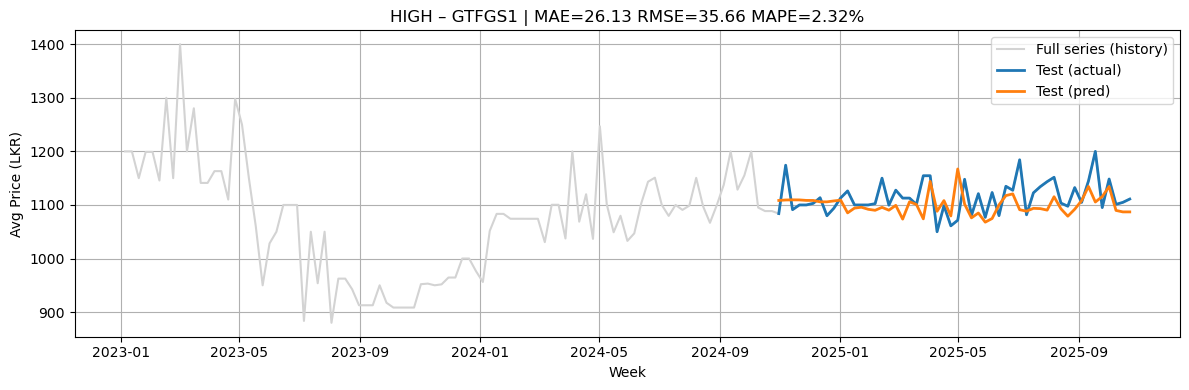

In [66]:
best_grade_high = metrics_high.iloc[0]["grade"]
plot_validation_high(best_grade_high)

In [67]:
# 12) Residual diagnostics (high)

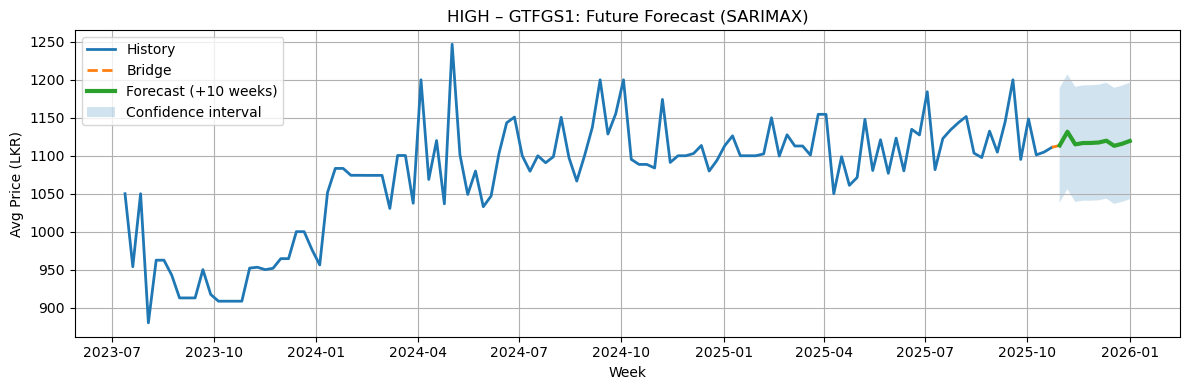

2025-10-30    1113.590421
2025-11-06    1131.573566
2025-11-13    1114.986090
2025-11-20    1116.761141
2025-11-27    1116.846781
2025-12-04    1117.443485
2025-12-11    1119.788526
2025-12-18    1113.068353
2025-12-25    1115.720997
2026-01-01    1119.448439
Freq: W-THU, Name: predicted_mean, dtype: float64

In [68]:
def forecast_future_high(grade, steps=10, show_last=120, connect=True):
    info = models_high[grade]
    y = info["y_full"]

    model_full = SARIMAX(
        y,
        order=info["order"],
        seasonal_order=info["seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False, maxiter=200)

    fc = model_full.get_forecast(steps=steps)
    y_fc = fc.predicted_mean
    ci = fc.conf_int()

    y_plot = y.iloc[-show_last:] if len(y) > show_last else y

    plt.figure(figsize=(12,4))
    plt.plot(y_plot.index, y_plot.values, linewidth=2, label="History")

    if connect and len(y_fc) > 0:
        x0 = y_plot.index[-1]
        y0 = y_plot.iloc[-1]
        x1 = y_fc.index[0]
        y1 = y_fc.iloc[0]
        plt.plot([x0, x1], [y0, y1], linestyle="--", linewidth=2, label="Bridge")

    plt.plot(y_fc.index, y_fc.values, linewidth=3, label=f"Forecast (+{steps} weeks)")
    plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.2, label="Confidence interval")

    plt.title(f"HIGH – {grade}: Future Forecast (SARIMAX)")
    plt.xlabel("Week")
    plt.ylabel("Avg Price (LKR)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return y_fc, ci

y_fc_high, ci_high = forecast_future_high(best_grade_high, steps=10)
y_fc_high

In [69]:
def residual_diagnostics_high(grade, lags=40):
    info = models_high[grade]
    resid = (info["y_test"] - info["y_pred_test"]).astype(float)

    # drop NaNs/inf
    resid = resid.replace([np.inf, -np.inf], np.nan).dropna()

    if len(resid) < 5:
        print(f"Not enough residual points to plot ACF (n={len(resid)}).")
        return

    # cap lags to a safe value
    max_lags = min(lags, len(resid) - 2, 30)   # 30 is a nice upper limit for readability
    if max_lags < 1:
        print(f"Not enough data for ACF (n={len(resid)}).")
        return

    plt.figure(figsize=(12,3))
    plt.plot(resid.index, resid.values)
    plt.title(f"high – {grade}: Residuals over time (Test) | n={len(resid)}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12,3))
    plot_acf(resid.values, lags=max_lags)
    plt.title(f"high – {grade}: Residual ACF (Test) | lags={max_lags}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.hist(resid.values, bins=20)
    plt.title(f"high – {grade}: Residual distribution (Test)")
    plt.tight_layout()
    plt.show()


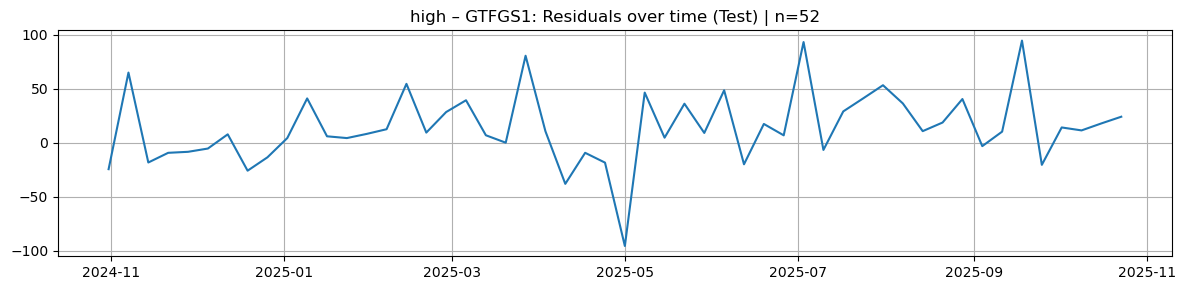

<Figure size 1200x300 with 0 Axes>

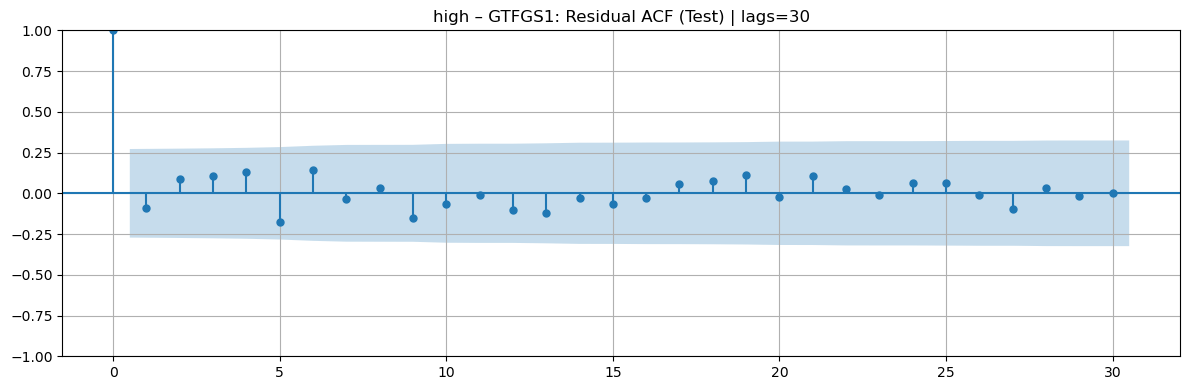

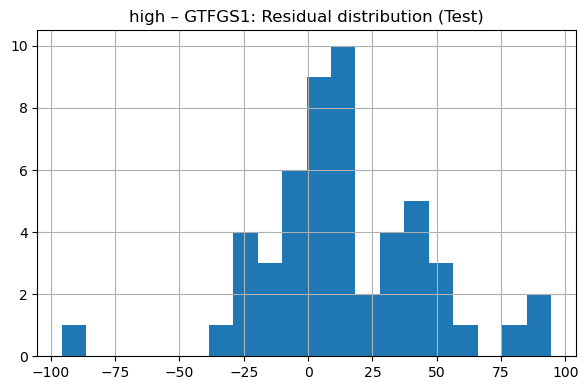

In [70]:
residual_diagnostics_high(best_grade_high, lags=40)


In [71]:
# 13) Future forecast plot (high) + confidence interval

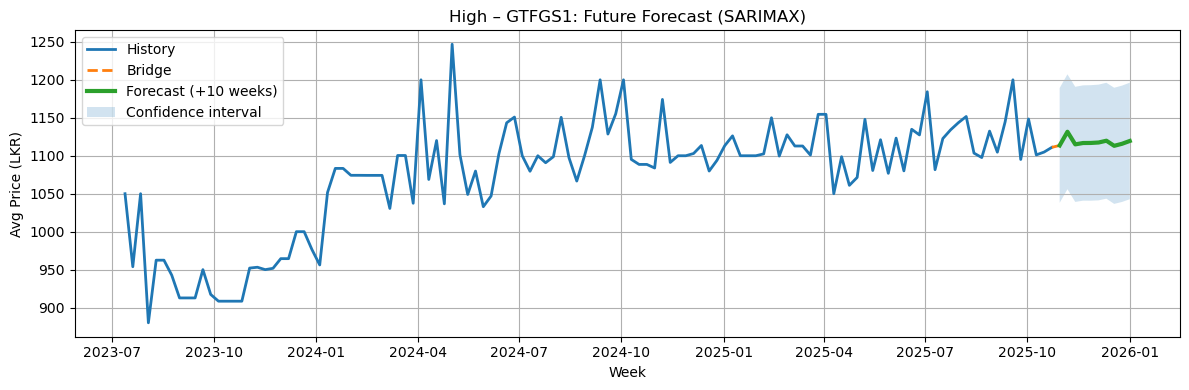

2025-10-30    1113.590421
2025-11-06    1131.573566
2025-11-13    1114.986090
2025-11-20    1116.761141
2025-11-27    1116.846781
2025-12-04    1117.443485
2025-12-11    1119.788526
2025-12-18    1113.068353
2025-12-25    1115.720997
2026-01-01    1119.448439
Freq: W-THU, Name: predicted_mean, dtype: float64

In [72]:
def forecast_future_high(grade, steps=10, show_last=120, connect=True):
    info = models_high[grade]
    y = info["y_full"]

    model_full = SARIMAX(
        y,
        order=info["order"],
        seasonal_order=info["seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False, maxiter=200)

    fc = model_full.get_forecast(steps=steps)
    y_fc = fc.predicted_mean
    ci = fc.conf_int()

    # zoom last part of history for visibility
    y_plot = y.iloc[-show_last:] if len(y) > show_last else y

    plt.figure(figsize=(12,4))
    plt.plot(y_plot.index, y_plot.values, linewidth=2, label="History")

    # connector so forecast looks continuous from last history point
    if connect and len(y_fc) > 0:
        x0 = y_plot.index[-1]
        y0 = y_plot.iloc[-1]
        x1 = y_fc.index[0]
        y1 = y_fc.iloc[0]
        plt.plot([x0, x1], [y0, y1], linestyle="--", linewidth=2, label="Bridge")

    # forecast as a LINE (no markers)
    plt.plot(y_fc.index, y_fc.values, linewidth=3, label=f"Forecast (+{steps} weeks)")

    plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.2, label="Confidence interval")

    plt.title(f"High – {grade}: Future Forecast (SARIMAX)")
    plt.xlabel("Week")
    plt.ylabel("Avg Price (LKR)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return y_fc, ci

y_fc, ci = forecast_future_high(best_grade_high, steps=10)
y_fc

In [73]:
# 14) Next-week predictions for ALL high grades

In [74]:
def next_week_predictions_high(models_high):
    out = []
    for grade, info in models_high.items():
        y = info["y_full"]

        model_full = SARIMAX(
            y,
            order=info["order"],
            seasonal_order=info["seasonal_order"],
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False, maxiter=200)

        next_pred = float(model_full.forecast(steps=1).iloc[0])
        next_date = y.index.max() + pd.to_timedelta(1, unit="W")
        out.append([grade, next_date.date(), next_pred])

    return pd.DataFrame(out, columns=["grade","next_week_date","pred_avg_price"]).sort_values("grade")

df_next_high = next_week_predictions_high(models_high)
df_next_high.head(30)

,grade,next_week_date,pred_avg_price
0,BM,2025-10-30,756.812350
1,BOP,2025-10-30,1227.329618
2,BOP1,2025-10-30,1310.662635
3,BOP1A,2025-10-30,820.518455
4,BOPA,2025-10-30,909.123021
5,BOPF,2025-10-30,1239.586301
6,BOPSP,2025-10-30,1288.211268
7,BP,2025-10-30,818.551606
8,BP1,2025-10-30,1197.354182
9,BT,2025-10-30,751.475376


In [75]:
from statsmodels.stats.diagnostic import acorr_ljungbox

def ljung_box_test_high(grade, lags=10):
    info = models_high[grade]
    resid = (info["y_test"] - info["y_pred_test"]).astype(float).dropna()

    lags = min(lags, len(resid)-2)
    lb = acorr_ljungbox(resid, lags=[lags], return_df=True)
    print(f"{grade} Ljung-Box (lag={lags}) p-value =", float(lb["lb_pvalue"].iloc[0]))

ljung_box_test_high("BOP1A", lags=10)


BOP1A Ljung-Box (lag=10) p-value = 7.528517991703249e-44


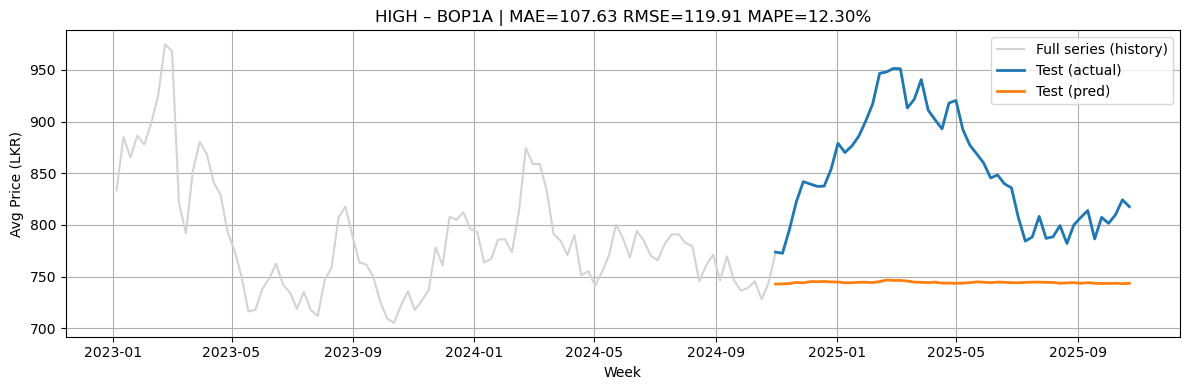

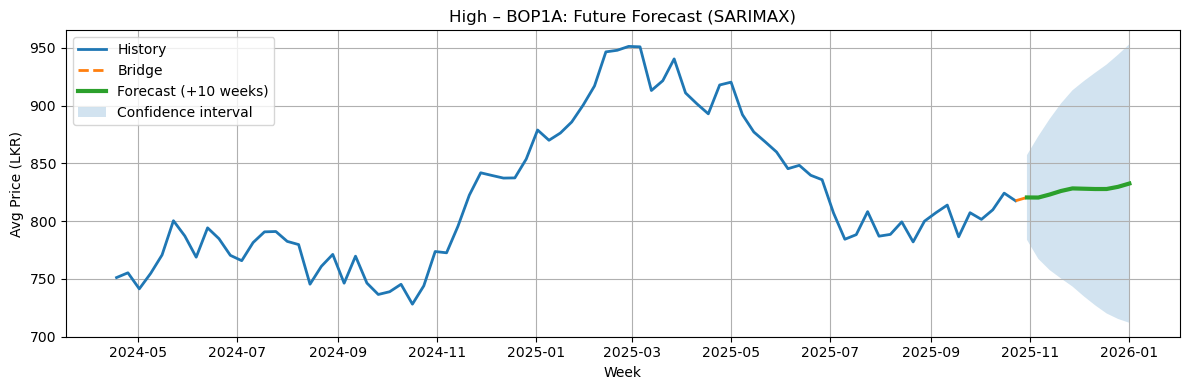

In [76]:
plot_validation_high("BOP1A")
y_fc, ci = forecast_future_high("BOP1A", steps=10, show_last=80, connect=True)

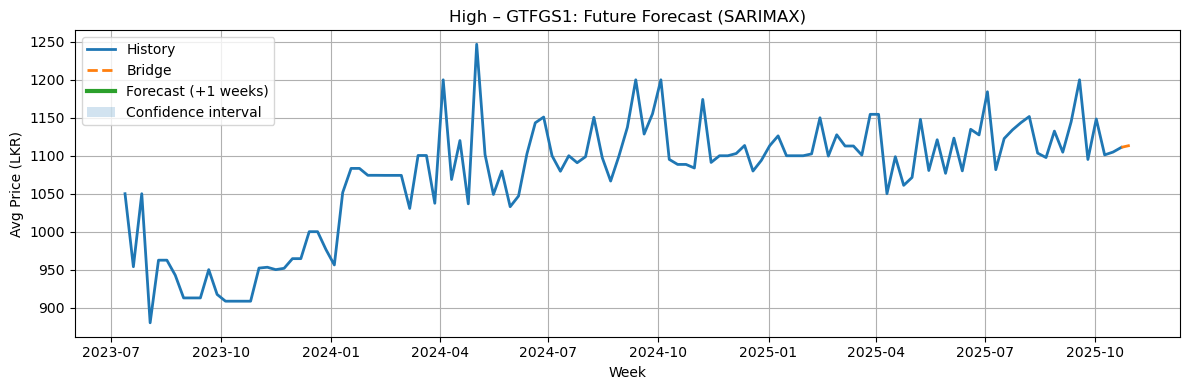

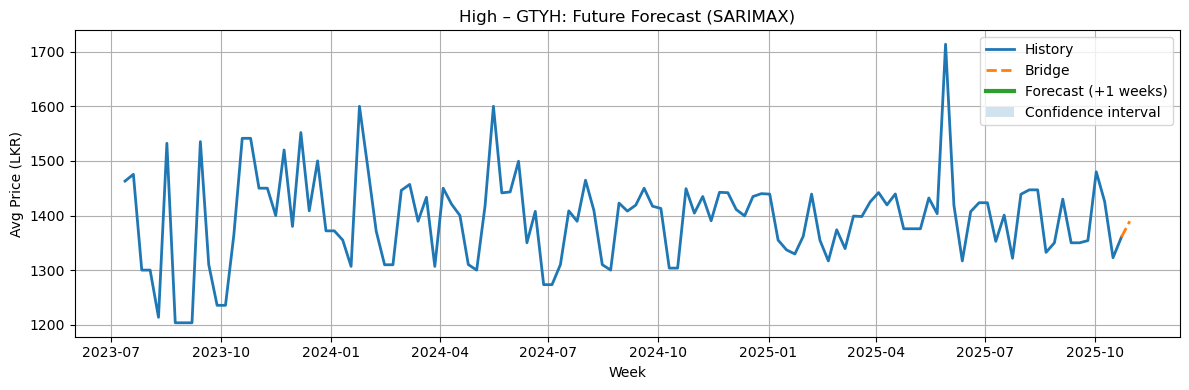

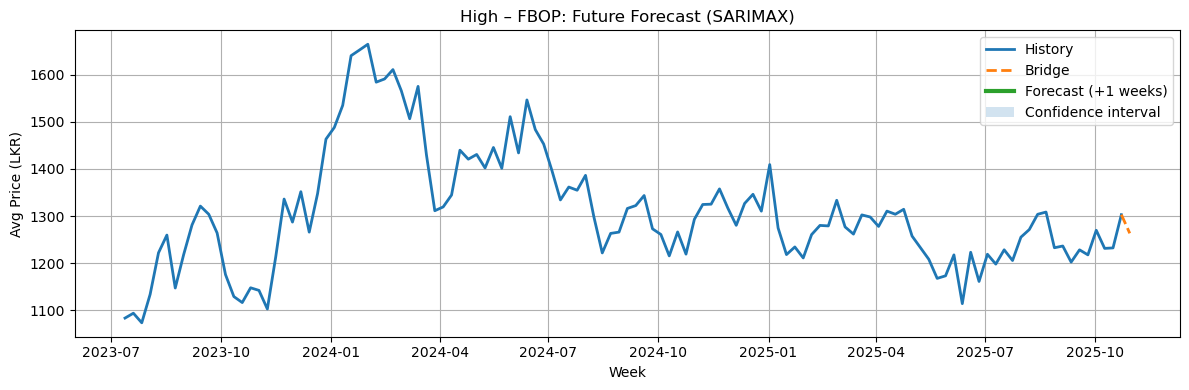

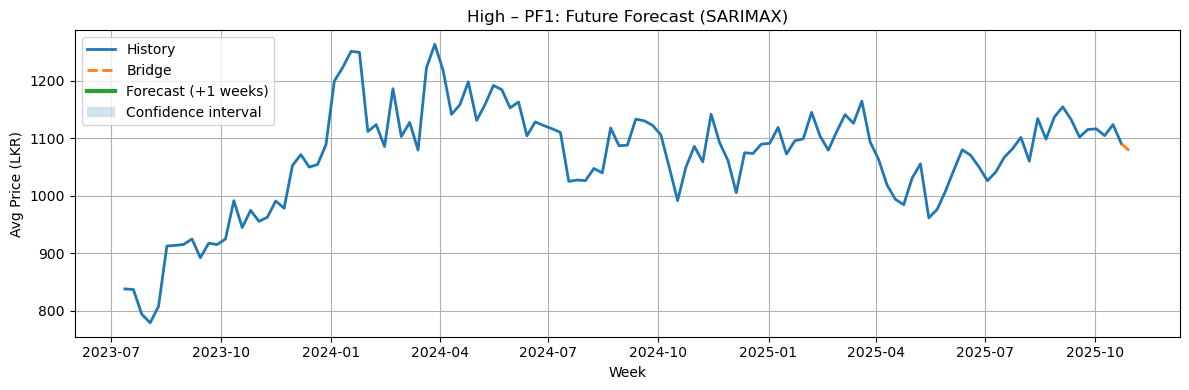

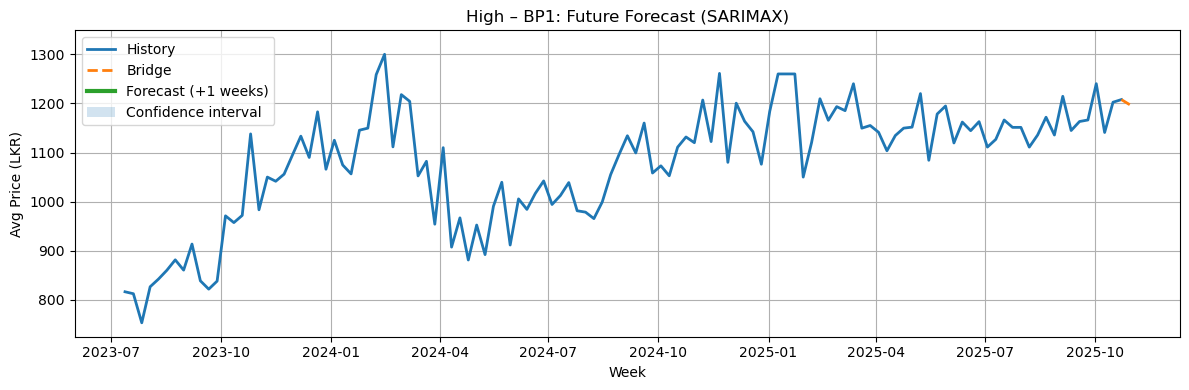

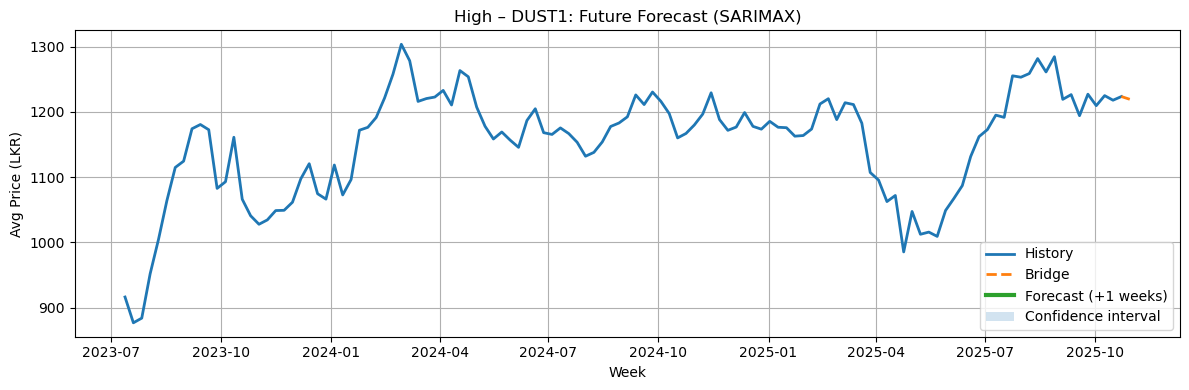

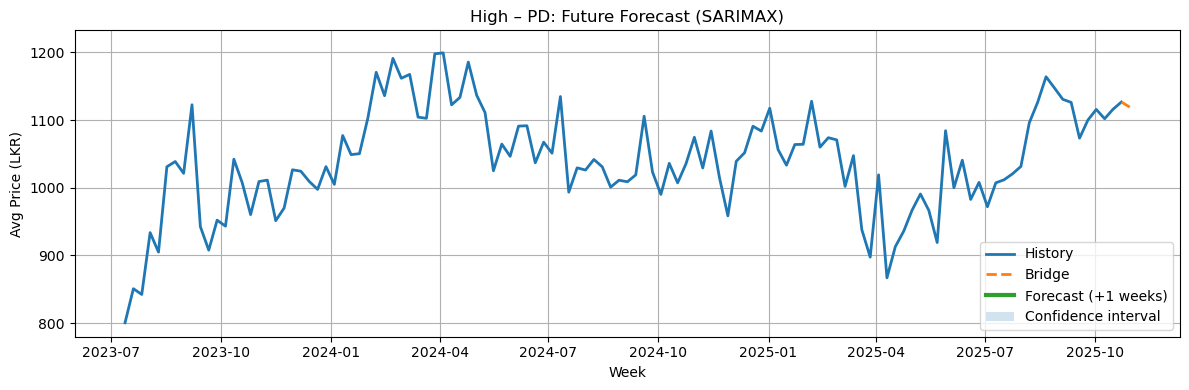

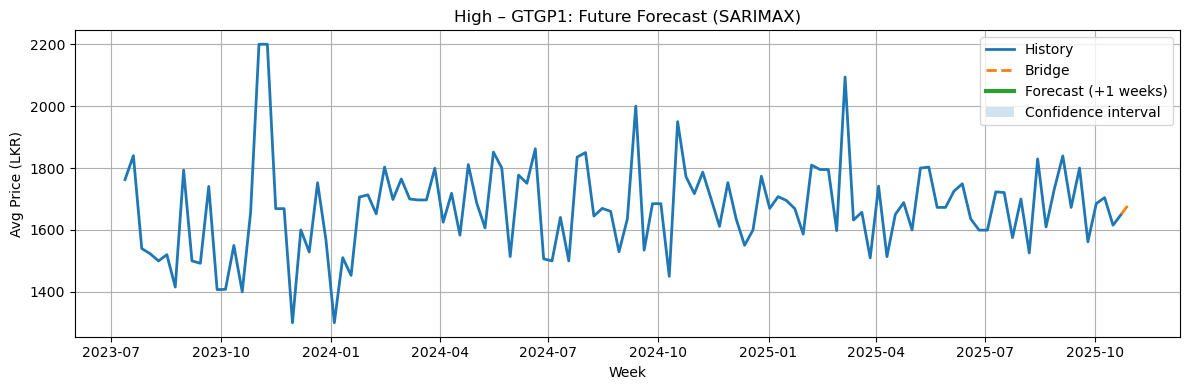

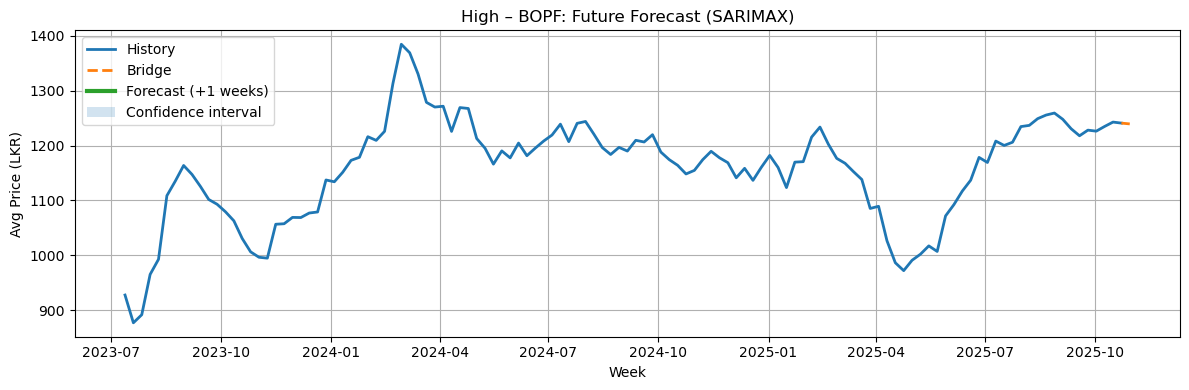

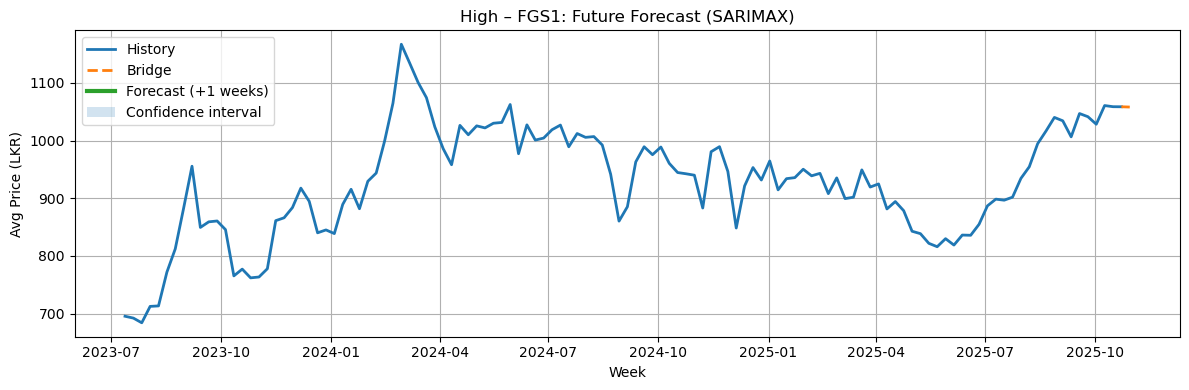

,grade,next_week_pred_price
7,GTGP1,1687.573267
1,GTYH,1389.427944
2,FBOP,1263.420629
8,BOPF,1239.586301
5,DUST1,1219.256658
4,BP1,1197.354182
6,PD,1119.127707
0,GTFGS1,1113.590421
3,PF1,1077.291448
9,FGS1,1058.065859


In [77]:
top_grades = metrics_high.head(10)["grade"].tolist()

preds = []
for g in top_grades:
    y_fc, _ = forecast_future_high(g, steps=1)
    preds.append([g, float(y_fc.iloc[0])])

pd.DataFrame(preds, columns=["grade","next_week_pred_price"]).sort_values("next_week_pred_price", ascending=False)


In [79]:
import pickle

# Save ALL high-elevation SARIMAX infos (includes fitted model object inside each grade)
with open("high_elevation_sarimax_models.pkl", "wb") as f:
    pickle.dump(models_high, f)

print("Saved all HIGH-elevation SARIMAX models to high_elevation_sarimax_models.pkl")


Saved all HIGH-elevation SARIMAX models to high_elevation_sarimax_models.pkl
